# Tutorial Goal: Flexibility with pandaprosumer

The purpose of this tutorial is to demonstrate how to set up a pandaprosumer container and configure controlled components such as heat pumps, CHP units, and thermal storage.  
By controlling the load of heat generators, we can actively provide **flexibility to the electrical grid**.  

The tutorial walks step by step through:
1. Creating a prosumer container,
2. Defining demand and generation profiles,
3. Adding controlled heat generators (BHP & CHP) and storage,
4. Mapping signals between components,
5. Create an optimization function for calculating the load of CHP and BHP for each timestep to provide the flexibility while meeting the heat demand of the system
6. Running a time series simulation and analyzing results.


The setup for the tutorial is shown in the following figure

![network](figures/setup_flexibility_provision.png)

### Import required packages

We start by importing the necessary Python libraries for data handling, plotting, optimization, and the pandaprosumer components.

In [35]:
import pandas as pd
from pandapower.timeseries.data_sources.frame_data import DFData
from pandaprosumer.create import create_empty_prosumer_container, create_period
from pandaprosumer.create_controlled import (create_controlled_const_profile, create_controlled_heat_demand, \
    create_controlled_booster_heat_pump, create_controlled_ice_chp, create_controlled_heat_storage)
from pandaprosumer.mapping import GenericMapping
from pandaprosumer.run_time_series import run_timeseries
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition

## Step 1: Create an empty prosumer container 

The prosumer container acts as the central data structure where all controlled components (heat pumps, CHP, storage, demand) are registered.

In [36]:
prosumer = create_empty_prosumer_container()

We define the period of the analysis by setting its start and end, which have the form "YYYY-MM-DD HH:MM:SS". The time resolution is given in [s].

In [37]:
start = '2020-01-01 00:00:00'
end = '2020-01-01 23:59:59'
time_resolution = 900        # 15 min
frequency = '15min'

## Step 2: Load time series input data

At first we import demand and control profiles from an Excel file.we define our flexibility demaand curve and add it to our time series data. Its a dummy curve, considering demand and PV-production

In [38]:
t = np.linspace(0, 24, 96)
L = (200 * np.exp(-((t - 8) ** 2) / (2 * 1.5 ** 2))
     + 200 * np.exp(-((t - 18) ** 2) / (2 * 1.5 ** 2)))
G_PV = 200 * np.maximum(0, np.sin(np.pi / 12 * (t - 6)))
flex = L - G_PV

Then we import demand and control profiles from an Excel file and add our flexibility demand. Afterwards we trnasform it to an DFData object. DFData is a pandaprosumer object that stores all data of an individual element. The DFData object is limited by the duration of the analysis defined above.

In [39]:
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name in ["tutorials", "tutorials_extended"] else Path.cwd()
data_file = project_root / "tutorials_extended" / "data" / "heat_demand_input_chp_bhp.xlsx"
time_series_data = pd.read_excel(data_file)

time_series_data["flex_demand_kw"] = flex

dur = pd.date_range(start=start, end=end, freq=frequency, tz='utc')
time_series_data.index = dur
time_series_input_bhp = DFData(time_series_data)
period = create_period(prosumer, time_resolution, start, end, 'utc', 'default')

time_series_data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/heat_demand_input_chp_bhp.xlsx'

The columns p_el_bhp and p_el_chp represent the electric consumption of the booster heat pump (BHP) and the electric generation of the combined heat and power unit (CHP). They are initially set to zero, since their values are calculated dynamically at each time step.

## Step 3: Define our nework Elements

At first we create our const profile

In [23]:
input_params = ['mode', 't_source_k', 'q_demand_kw', 'cycle', 't_intake_k',
                    "flex_demand_kw", "p_el_bhp", "p_el_chp"]
result_params = ['mode_cp', 't_source_cp_k', 'q_demand_cp_kw', 'cycle_cp', 't_intake_cp_k',
                     "flex_demand_cp_kw", "p_el_bhp_cp", "p_el_chp_cp"]

cp_index = create_controlled_const_profile(
        prosumer, input_params, result_params, time_series_input_bhp, period, level=0)

Then we define our BHP

In [24]:
bhp_type = 'water-water1'
bhp_name = 'example_bhp'
max_thermal_power_kw = 700

bhp_index = create_controlled_booster_heat_pump(prosumer, 
                                                hp_type=bhp_type, 
                                                name=bhp_name, 
                                                q_max_kw=max_thermal_power_kw, 
                                                level=1, 
                                                order=0)

Then we define the CHP

In [25]:
name = 'example_chp'
size_kw = 700
fuel = 'ng'
altitude_m = 0

ice_chp_index = create_controlled_ice_chp(prosumer, size_kw, fuel, altitude_m, name, level=1, order=1)

The heat storage

In [26]:
q_capacity_kwh = 10000

heat_storage_index = create_controlled_heat_storage(prosumer, q_capacity_kwh, level=1, order=2)

And the heat demand

In [27]:
heat_demand_index = create_controlled_heat_demand(prosumer, scaling=1.0, level=1, order=3)

## Mapping signals between components

In this step we map the input data from the const profile to the model controllers, aswell as the dataflow between the model controllers

In [28]:
GenericMapping(prosumer,
        initiator_id=cp_index,
        initiator_column=["t_source_cp_k", "mode_cp","p_el_bhp_cp"],
        responder_id=bhp_index,
        responder_column=["t_source_k", "mode", "p_received_kw"],
    )

GenericMapping(
        prosumer,
        initiator_id=cp_index,
        initiator_column=["cycle_cp", "t_intake_cp_k", "p_el_chp_cp"],
        responder_id=ice_chp_index,
        responder_column=["cycle", "t_intake_k", "p_requested_kw"],
    )


GenericMapping(prosumer,
        initiator_id=cp_index,
        initiator_column="q_demand_cp_kw",
        responder_id=heat_demand_index,
        responder_column="q_demand_kw",
    )

GenericMapping(prosumer,
                initiator_id=bhp_index,
                initiator_column="q_floor",
                responder_id=heat_storage_index,
                responder_column="q_received_kw",
                order=0,
)

GenericMapping(
    prosumer,
    initiator_id=ice_chp_index,
    initiator_column="p_th_out_kw",
    responder_id=heat_storage_index,
    responder_column="q_received_kw",
    order=1,
)


GenericMapping(
    prosumer,
    initiator_id=heat_storage_index,
    initiator_column="q_delivered_kw",
    responder_id=heat_demand_index,
    responder_column="q_received_kw",
)

## Step 5: Create an optimization function for calculating the load of CHP and BHP for each timestep to provide the flexibility while meeting the heat demand of the system

Now coes the crucial part. We define a check_results function, that checks the results of an initial controller run. If the conditiotn (meeting the flexibility demand) is met, the next time step follows. If not, an optimization happens where the optimal electric consumption of the BHP and the electric generation of the CHP is calculated to minimize deviations to the flexibility demand while meeting the requested heat demand of the system.

For the optimization we need the relations between electric power production/generation and heat generation of the BHP and CHP. While this relation for the BHP is the COP, that is calculated in the initial run, for the CHP we need a fitting curve for the relation, based on the chp map. This function uses the least squared regression for a function with a chosen degree is shown below:

In [29]:
def fit_chp_relations(chp_map, degree=1):
    p_el = np.array(chp_map["power_el_kw"], dtype=float)
    q_th = np.array(chp_map["heat_flow_recovered_kw"], dtype=float)

    # Sort by electrical output
    idx = np.argsort(p_el)
    p_el, q_th = p_el[idx], q_th[idx]

    # Build Vandermonde matrix for polynomial fitting
    X = np.vander(p_el, N=degree + 1, increasing=True)

    # Least Squares Fit: q_th = f(p_el)
    coefficients, *_ = np.linalg.lstsq(X, q_th, rcond=None)

    return coefficients.tolist()

Then we show formulate our optimization Problem. The function builds and solves a mixed‑integer nonlinear optimization model (MINLP) with Pyomo to determine the optimal dispatch of a CHP unit, booster heat pump, and thermal storage.
The model balances heat and electricity demand while minimizing overall electrical consumption. The optimization decides on what load to run the CHP, how much the heat pump consumes, and how the storage charges/discharges.

The inputs are the heat and flexibilits demand, the COP and maximaum thermal output of the BHP, the Map of the chosen CHP, the SOC and maximum capacity of the storage and the time resolution.

Outputs are the targeted electric consumption of the BHP and electric generation of the CHP.

In [30]:
def model_optimization(heat_demand, flex_demand, cop_bhp, soc, chp_map,
                               resol, storage_cap, q_bhp_max=700):
    m = pyo.ConcreteModel()

    # Parameter
    m.heat_demand = pyo.Param(initialize=heat_demand)
    m.flex_demand = pyo.Param(initialize=flex_demand)
    m.cop_bhp     = pyo.Param(initialize=cop_bhp)
    m.q_th_bhp_max   = pyo.Param(initialize=q_bhp_max)
    m.soc         = pyo.Param(initialize=soc)
    m.storage_cap = pyo.Param(initialize=storage_cap)
    m.resol       = pyo.Param(initialize=resol)

    # decision variables for electrical input (BHP) and output (CHP)
    m.p_el_bhp  = pyo.Var(domain=pyo.NonNegativeReals)  # BHP power consumption
    m.p_el_chp = pyo.Var(domain=pyo.NonNegativeReals)  # CHP power generation

    # binary Variable for chp. To turn the chp of ig´f the load is out of bounds
    m.y_chp = pyo.Var(domain=pyo.Binary)

    nominal_size_chp = chp_map["__chp_nominal_size_kw__"]
    load_min, load_max = chp_map["load_limits_percent"]

    # Convert to absolute electrical bounds
    p_el_min_chp = (load_min / 100.0) * nominal_size_chp
    p_el_max_chp = (load_max / 100.0) * nominal_size_chp

    #Bound Constraints CHP
    m.p_el_chp_min = pyo.Constraint(expr=m.p_el_chp >= p_el_min_chp * m.y_chp)
    m.p_el_chp_max = pyo.Constraint(expr=m.p_el_chp <= p_el_max_chp * m.y_chp)

    # variables thermal output
    m.q_th_bhp  = pyo.Var(domain=pyo.NonNegativeReals)  
    m.q_th_chp = pyo.Var(domain=pyo.NonNegativeReals)

    ## Relation between thermal and electric ouput CHP
    # coefficient of the fit curve of thermal and electric output of the CHP
    fit = fit_chp_relations(chp_map, degree=1)
    coeff_HE = fit
    
    M_chp = 5000  # Big-M
    #  Link q_th_chp to polynomial of p_el_chp only if CHP is on (y_chp = 1), relaxed otherwise
    m.q_th_chp_upper = pyo.Constraint(
        expr=m.q_th_chp <= poly_expr(coeff_HE, m.p_el_chp) + M_chp * (1 - m.y_chp)
    )
    m.q_th_chp_lower = pyo.Constraint(
        expr=m.q_th_chp >= poly_expr(coeff_HE, m.p_el_chp) - M_chp * (1 - m.y_chp)
    )

    # If the CHP is off (y=0) no thermal output is allowed.
    m.q_th_chp_off = pyo.Constraint(expr=m.q_th_chp <= M_chp * m.y_chp)

    # Relation between thermal and electric ouput BHP
    m.q_th_bhp = pyo.Expression(expr= m.cop_bhp * m.p_el_bhp)

    # capacity bound for the BHP
    m.hp_cap = pyo.Constraint(expr=m.q_th_bhp <= m.q_th_bhp_max)

    # stoage variables
    m.q_th_charge    = pyo.Var(domain=pyo.NonNegativeReals)
    m.q_th_discharge = pyo.Var(domain=pyo.NonNegativeReals)

    # Binary-vriables storage
    m.y_charge = pyo.Var(domain=pyo.Binary)
    m.y_discharge = pyo.Var(domain=pyo.Binary)

    #allows to only charge or discharge the storage. Not both at the same time.
    m.charge_discharge = pyo.Constraint(expr=m.y_discharge + m.y_charge <= 1)

    #bounds for charging or discharging the storge dependend on the soc
    m.q_th_charge_max   = pyo.Constraint(expr=m.q_th_charge <= m.storage_cap * (1 - m.soc) * m.resol / 3600 * m.y_charge)
    m.q_th_discharge_max = pyo.Constraint(expr=m.q_th_discharge <= m.storage_cap * m.soc * m.resol / 3600 * m.y_discharge)

    # balances
    m.heat_bal = pyo.Constraint(expr=m.q_th_bhp + m.q_th_chp + m.q_th_discharge - m.q_th_charge == m.heat_demand)
    m.el_bal   = pyo.Expression(expr=-m.p_el_bhp + m.p_el_chp - m.flex_demand)

    # objective to minimize the electric power consumption of the whole system.
    m.obj = pyo.Objective(
        expr=m.el_bal**2 - m.q_th_charge,
        sense=pyo.minimize
    )

    # Solver
    solver = pyo.SolverFactory('mindtpy')
    results = solver.solve(m, strategy='OA', mip_solver='glpk', nlp_solver='ipopt')

    if (results.solver.status == SolverStatus.ok and
        results.solver.termination_condition == TerminationCondition.optimal):
        return {
            "p_el_bhp": pyo.value(m.p_el_bhp),
            "p_el_chp": pyo.value(m.p_el_chp),
            "feasible": True
        }
    else:
        return {"feasible": False}

def poly_expr(coeffs, x):
    return sum(coeffs[i] * (x**i) for i in range(len(coeffs)))

Now we formulte the function that checks if our condition (meetingthe flexibility demand) is met and decides based on the results if the optimizatian takes place and there is a rerun of the controller in the timestep based on the reults of the optimization.

- Rerun is False
- Extract the results of the initial run of the timestep.
- Extract the input data for the timestep
- If our conditiotn is not met, run the optimization
- Change the input data for the rerun of the timestep
- Return rerun is True

In [31]:
def check_results(prosumer, ts):
    rerun = False

    resol = prosumer.period.resolution_s[0]
    #previous timestep
    ts_prev = ts - pd.Timedelta(seconds=resol)

    #Results for the timestep
    results_timestep = prosumer.controller_results

    #result data for el. power for the timestep (bhp - input, chp - output)
    p_el_out_chp = results_timestep[ts][2]["p_el_out_kw"]
    p_el_floor_bhp = results_timestep[ts][1]["pel_floor_kw"]

    #select the chp_map for the optimization
    here = os.getcwd()              # aktuelles Arbeitsverzeichnis
    parent = os.path.dirname(here)  # ein Ordner zurück
    path = os.path.join(parent, "src", "pandaprosumer", "library", "chp_maps", "ice_chp_maps.json")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    chp_map_2 = next(m for m in data["chp_ice_map"] if m["__chp_nominal_size_kw__"] == size_kw)

    cop_bhp = results_timestep[ts][1]["cop_floor"]
    if ts_prev in results_timestep:
        soc = results_timestep[ts_prev][3]["soc"]
    else:
        # first timestep → SOC = 0
        soc = 0.0

    #DFData - DataSourceClass for the input data
    df_data = prosumer.controller.object[0].df_data
    # input data for the const. profile for the timestep
    row = df_data.df.loc[ts, prosumer.controller.object[0].input_columns]

    #node balance for the timestep
    node_balance = p_el_out_chp - p_el_floor_bhp + row["flex_demand_kw"]

    if abs(node_balance) >= 1e-2:
        results = model_optimization(
            heat_demand=row["q_demand_kw"],
            flex_demand=row["flex_demand_kw"],
            cop_bhp=cop_bhp,
            soc=soc,
            chp_map=chp_map_2,
            q_bhp_max=max_thermal_power_kw,
            storage_cap=q_capacity_kwh,
            resol=resol,
        )

        if results["feasible"]:
            #put the results of the optimization as input data for the const profile for the rerun of the timestep
            df_data.df.loc[ts, "p_el_bhp"] = results["p_el_bhp"]
            df_data.df.loc[ts, "p_el_chp"] = results["p_el_chp"]

            rerun = True
        else:
            rerun = False

    return rerun

## 6. Running a time series simulation and analyzing results.

we run the timeseries with our check_results function passed as an argument.

In [32]:
run_timeseries(prosumer, period, check_results_fct=check_results, verbose=True)

100%|██████████| 96/96 [00:28<00:00,  3.38it/s]


We store our results in a DataFrame

In [33]:
res_bhp, res_chp, res_storage, res_heat_demand = [
    prosumer.time_series.data_source.iloc[i].df for i in range(4)
]

res_df = pd.DataFrame({
    "chp_p_el": res_chp["p_el_out_kw"],
    "bhp_p_el": -res_bhp["p_el_floor"],
    "chp_q_th": res_chp["p_th_out_kw"],
    "bhp_q_th": res_bhp["q_floor"],
    "flex": flex,
    "p_el_balance": res_chp["p_el_out_kw"] - res_bhp["p_el_floor"] - flex,
    "p_el_sum": res_chp["p_el_out_kw"] - res_bhp["p_el_floor"],
    "q_th_sum": res_chp["p_th_out_kw"] + res_bhp["q_floor"],
    "q_delivered_storage": res_storage["q_delivered_kw"],
    "soc": res_storage["soc"] * 100,
    "q_received_demand": res_heat_demand["q_received_kw"],
}, index=res_chp.index)

And plot them

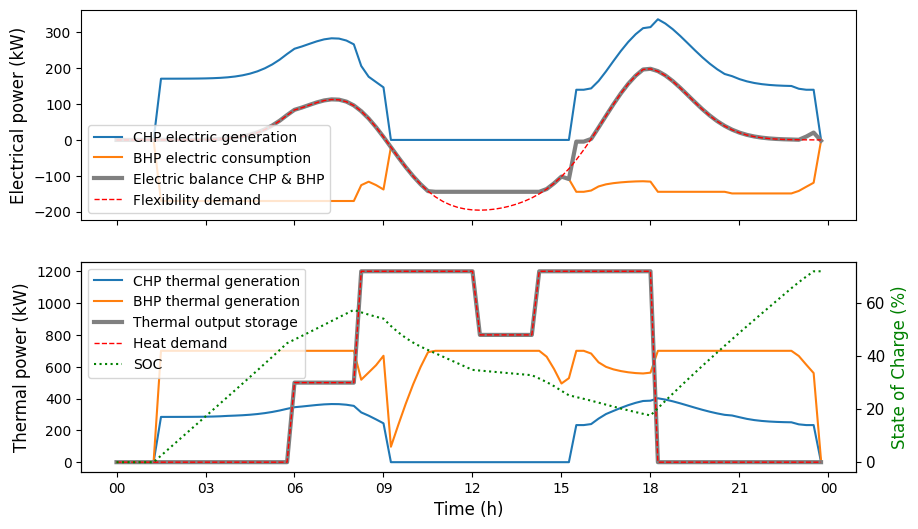

In [107]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(res_df.index, res_df["chp_p_el"], label="CHP electric generation")
ax[0].plot(res_df.index, res_df["bhp_p_el"], label="BHP electric consumption")
ax[0].plot(res_df.index, res_df["p_el_sum"], label="Electric balance CHP & BHP", linewidth=3, color="grey")
ax[0].plot(res_df.index, res_df["flex"], label="Flexibility demand", color="red", linewidth=1, linestyle="--")
ax[0].set_ylabel("Electrical power (kW)", fontsize=12)
ax[0].legend(fontsize=10, loc="lower left")

ax[1].plot(res_df.index, res_df["chp_q_th"], label="CHP thermal generation")
ax[1].plot(res_df.index, res_df["bhp_q_th"], label="BHP thermal generation")
ax[1].plot(res_df.index, res_df["q_delivered_storage"], label="Thermal output storage", linewidth=3, color="grey")
ax[1].plot(res_df.index, res_df["q_received_demand"], label="Heat demand", color="red", linewidth=1, linestyle="--")
ax[1].set_ylabel("Thermal power (kW)", fontsize=12)
ax[1].legend(fontsize=10)

ax2 = ax[1].twinx()
ax2.plot(res_df.index, res_df["soc"], linestyle=':', label="SOC", color="green", linewidth=1.5)
ax2.set_ylabel("State of Charge (%)", fontsize=12, color="green")


lines1, labels1 = ax[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

hour_fmt = mdates.DateFormatter("%H")   # %H = Stunde (00–23)
ax[1].xaxis.set_major_formatter(hour_fmt)
ax[1].set_xlabel("Time (h)", fontsize=12)

plt.xticks(fontsize=11)   # x-Achse Tick-Beschriftungen größer
plt.yticks(fontsize=11)   # y-Achse Tick-Beschriftungen größer

# Plot fertig zeichnen
plt.draw()

plt.show()